# Trade-Flow Benchmark — Cross-Experiment Comparison

Pulls together results from every experiment run so far:

1. **Shrinkage-head model**, trained on `all_products_ready.parquet` (19 configs: GAT × fusion × scoring, EdgeGAT_full × fusion × scorer-combo)
2. **Dedicated chips-only model**, trained only on `chips.parquet` (same 19 configs, plain shared weights, no per-product head)
3. **Per-heading head without shrinkage** (the earlier version, before hierarchical pooling was added)
4. **Permutation feature importance**, chips vs. electronics

The central question this notebook answers: **does one pooled model with a lightweight per-product head match or beat a model trained specifically for chips (HS 8541+8542)?**

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#111111', 'axes.facecolor': '#111111', 'savefig.facecolor': '#111111',
    'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 10,
})
BLUE, ORANGE, POS, NEG = '#4c8fbd', '#c47f3e', '#2ca02c', '#d62728'

shrink            = pd.read_csv('results_shrinkage_head.csv')
chips_dedicated   = pd.read_csv('results_v2_chips_reproduced.csv')
noshrink          = pd.read_csv('results_perproduct_head.csv')
fi_all            = pd.read_csv('feature_importance_all.csv')
fi_chips          = pd.read_csv('feature_importance_chips.csv')

chips_dedicated = chips_dedicated.drop_duplicates(
    ['model','fusion','scoring','gdelt','risk_level','agg_mode','missing','tranche'], keep='last')
chips_dedicated = chips_dedicated[chips_dedicated.tranche == 'all']

print('shrinkage rows:', len(shrink), '| chips-dedicated rows:', len(chips_dedicated),
      '| no-shrinkage rows:', len(noshrink), '| feature-importance rows:', len(fi_all))

shrinkage rows: 18107 | chips-dedicated rows: 19 | no-shrinkage rows: 3808 | feature-importance rows: 178


## 1. Shrinkage-head model — overall performance (all 19 configs, all-products test set)

Full grid: GAT (no-GDELT + keepall/topk × concat/blend/attention) and EdgeGAT_full (4 scorer combos × 3 fusions), all trained together on the full pooled dataset with the hierarchical per-heading shrinkage head.

,model,log_r2,spearman,n
10483,EdgeGAT_full_blend_ka_tk_shrinkage,0.366416,0.624886,123777
4765,GAT_first_topk_blend_shrinkage,0.340890,0.599489,123777
15248,EdgeGAT_full_concat_tk_tk_shrinkage,0.340315,0.595488,123777
14295,EdgeGAT_full_attention_tk_ka_shrinkage,0.338885,0.609272,123777
16201,EdgeGAT_full_blend_tk_tk_shrinkage,0.337731,0.587633,123777
9530,EdgeGAT_full_concat_ka_tk_shrinkage,0.335360,0.583811,123777
953,GAT_first_keepall_concat_shrinkage,0.333311,0.587799,123777
12389,EdgeGAT_full_concat_tk_ka_shrinkage,0.330584,0.582056,123777
13342,EdgeGAT_full_blend_tk_ka_shrinkage,0.321094,0.586859,123777
7624,EdgeGAT_full_blend_ka_ka_shrinkage,0.318773,0.606032,123777


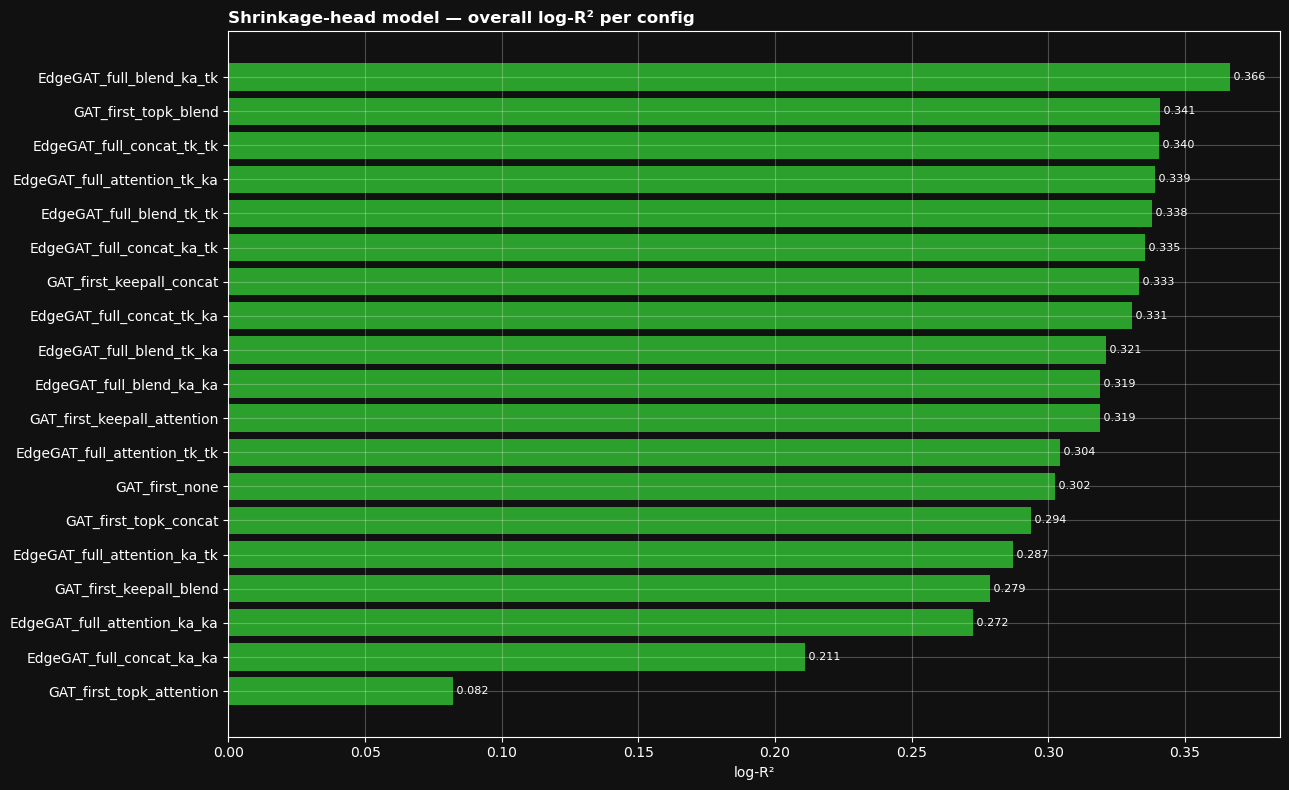

In [2]:
overall = shrink[shrink.scope == 'overall'].sort_values('log_r2', ascending=False)

fig, ax = plt.subplots(figsize=(13, 8))
colors = [POS if v >= 0 else NEG for v in overall['log_r2']]
ax.barh(overall['model'].str.replace('_shrinkage',''), overall['log_r2'], color=colors)
ax.set_xlabel('log-R²'); ax.set_title('Shrinkage-head model — overall log-R² per config', loc='left', fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(overall['log_r2']):
    ax.text(v, i, f' {v:.3f}', va='center', fontsize=8)
fig.tight_layout()

overall[['model','log_r2','spearman','n']]

## 2. The key test — pooled + shrinkage on HS 8541+8542 vs. the dedicated chips-only model

For each of the 19 configs, compares the shrinkage model's `HS_8541_8542_combined` slice (evaluated on just those two headings, out of the *full* pooled test set) against the equivalent model trained *only* on `chips.parquet`.

**Caveat worth keeping in mind:** the two populations aren't identical in size (`n≈378` for the pooled slice vs. `n=1,611` for the dedicated chips run) — different train/test construction paths, not the same exact rows. Treat this as a strong directional signal, not a bit-for-bit apples-to-apples test.

In [3]:
def parse_shrinkage_name(name):
    """Maps a shrinkage-model name back to (model, fusion, scoring) so it can be
    joined against results_v2_chips_reproduced.csv's columns."""
    n = name.replace('_shrinkage', '')
    if n == 'GAT_first_none':
        return ('GAT', 'none', 'none')
    if n.startswith('GAT_first_'):
        rest = n[len('GAT_first_'):]
        scoring, fusion = rest.rsplit('_', 1)
        return ('GAT', fusion, scoring)
    if n.startswith('EdgeGAT_full_'):
        rest = n[len('EdgeGAT_full_'):]
        fusion, combo = rest.split('_', 1)
        return ('EdgeGAT_full', fusion, combo)
    raise ValueError(name)

combo_rows = shrink[shrink.scope == 'HS_8541_8542_combined']
rows = []
for _, row in combo_rows.iterrows():
    m, f, s = parse_shrinkage_name(row['model'])
    match = chips_dedicated[(chips_dedicated.model==m) & (chips_dedicated.fusion==f) & (chips_dedicated.scoring==s)]
    if len(match) == 0:
        print(f'  [warn] no dedicated-chips match for {row["model"]} -> {(m,f,s)}')
        continue
    rows.append({
        'label': row['model'].replace('_shrinkage', ''),
        'pooled_shrinkage_8541_8542': row['log_r2'],
        'dedicated_chips_only': match.iloc[0]['log_r2'],
        'pooled_n': row['n'], 'dedicated_n': match.iloc[0]['n'],
    })

comp = pd.DataFrame(rows).set_index('label')
comp['delta'] = comp['pooled_shrinkage_8541_8542'] - comp['dedicated_chips_only']
comp = comp.sort_values('delta', ascending=False)

n_beat = (comp['delta'] > 0).sum()
print(f'Pooled+shrinkage beats the dedicated chips-only model in {n_beat} / {len(comp)} configs.')
comp

Pooled+shrinkage beats the dedicated chips-only model in 17 / 19 configs.


,pooled_shrinkage_8541_8542,dedicated_chips_only,pooled_n,dedicated_n,delta
label,,,,,
EdgeGAT_full_blend_ka_tk,0.497180,0.1784,378,1611,0.318780
EdgeGAT_full_blend_tk_ka,0.489327,0.1990,378,1611,0.290327
EdgeGAT_full_concat_ka_tk,0.498457,0.2369,378,1611,0.261557
EdgeGAT_full_concat_tk_tk,0.478672,0.2284,378,1611,0.250272
EdgeGAT_full_concat_tk_ka,0.469630,0.2217,378,1611,0.247930
EdgeGAT_full_attention_tk_ka,0.455296,0.2421,378,1611,0.213196
EdgeGAT_full_attention_tk_tk,0.478722,0.2698,378,1611,0.208922
GAT_first_keepall_attention,0.466139,0.2599,378,1611,0.206239
EdgeGAT_full_blend_ka_ka,0.478118,0.3083,378,1611,0.169818


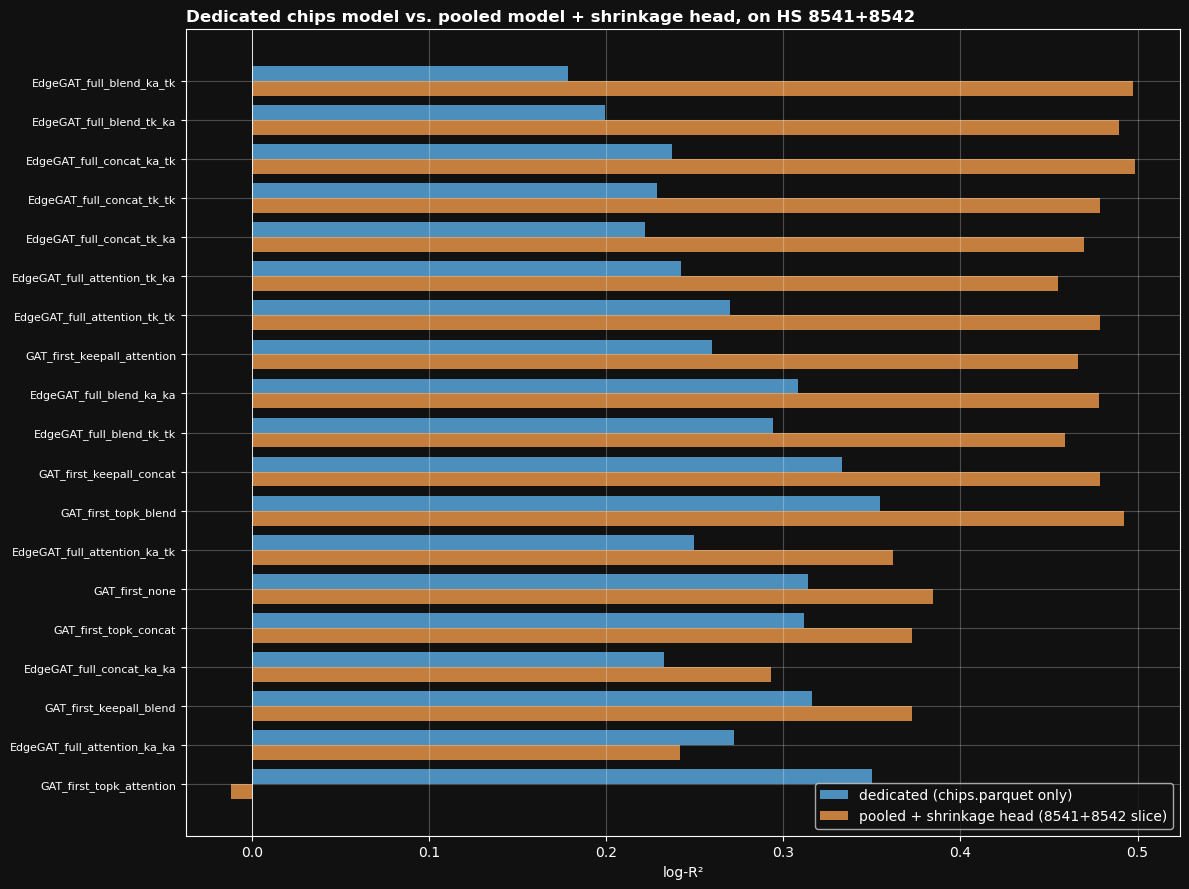

In [4]:
fig, ax = plt.subplots(figsize=(12, 9))
x = np.arange(len(comp)); w = 0.38
ax.barh(x - w/2, comp['dedicated_chips_only'], w, label='dedicated (chips.parquet only)', color=BLUE)
ax.barh(x + w/2, comp['pooled_shrinkage_8541_8542'], w, label='pooled + shrinkage head (8541+8542 slice)', color=ORANGE)
ax.set_yticks(x); ax.set_yticklabels(comp.index, fontsize=8)
ax.axvline(0, color='w', lw=.6)
ax.set_xlabel('log-R²'); ax.set_title('Dedicated chips model vs. pooled model + shrinkage head, on HS 8541+8542', loc='left', fontweight='bold')
ax.legend(loc='lower right')
ax.invert_yaxis()
fig.tight_layout()

## 3. Drilling into 8541 vs. 8542 separately — no-shrinkage per-heading version

`results_perproduct_head.csv` is from the earlier per-heading run *without* the hierarchical shrinkage on top — useful here because it reports 8541 and 8542 as two separate rows (the shrinkage file only has them combined). Only 4 models were trained in that earlier run, but it's worth checking whether the two headings behave similarly or one is doing all the work.

In [5]:
ph = noshrink[(noshrink.scope == 'per_chapter') & (noshrink.chapter.isin([8541, 8542]))].copy()
ph['heading'] = ph['chapter'].astype(int)
ph_piv = ph.pivot_table(index='model', columns='heading', values='log_r2')
ph_piv.columns = [f'HS_{c}' for c in ph_piv.columns]
ph_piv['gap_8542_minus_8541'] = ph_piv['HS_8542'] - ph_piv['HS_8541']
ph_piv

,HS_8541,HS_8542,gap_8542_minus_8541
model,,,
EdgeGAT_full_attention_ka_ka_perproduct,0.395855,0.492384,0.096530
EdgeGAT_full_blend_tk_tk_perproduct,0.428300,0.553445,0.125146
GAT_first_none_perproduct,0.357309,0.552318,0.195009
GAT_first_topk_perproduct,0.427446,0.587048,0.159602


## 4. Feature importance — chips vs. electronics

Permutation importance (per-feature score drop when that column is shuffled), averaged across every model that tested each feature, per dataset. `refYear` excluded — it's constant in the 2023-only eval set, so permutation importance can't measure it (not evidence it's unused).

In [6]:
EXCLUDE = {'refYear', 'node:refYear'}
fi = fi_all[~fi_all['feature'].isin(EXCLUDE)].copy()
fi['feature_clean'] = fi['feature'].apply(lambda f: f.split(':', 1)[-1] if ':' in f else f)

agg = fi.groupby(['feature_clean', 'dataset'])['importance_log_r2'].mean().unstack().round(4)
agg['abs_gap'] = (agg['chips'] - agg['electronics']).abs()
agg = agg.sort_values('chips', ascending=False)
agg

dataset,chips,electronics,abs_gap
feature_clean,,,
gdpcap_o,0.1687,0.2502,0.0815
score_mean,0.1443,0.1244,0.0199
tone_mean,0.1408,0.1191,0.0217
pop_o,0.1034,0.1584,0.0550
active_months,0.0767,0.0963,0.0196
events_total,0.0685,0.1159,0.0474
goldstein_wmean,0.0657,0.1108,0.0451
dist,0.0448,0.0324,0.0124
score_vol,0.0364,0.0210,0.0154


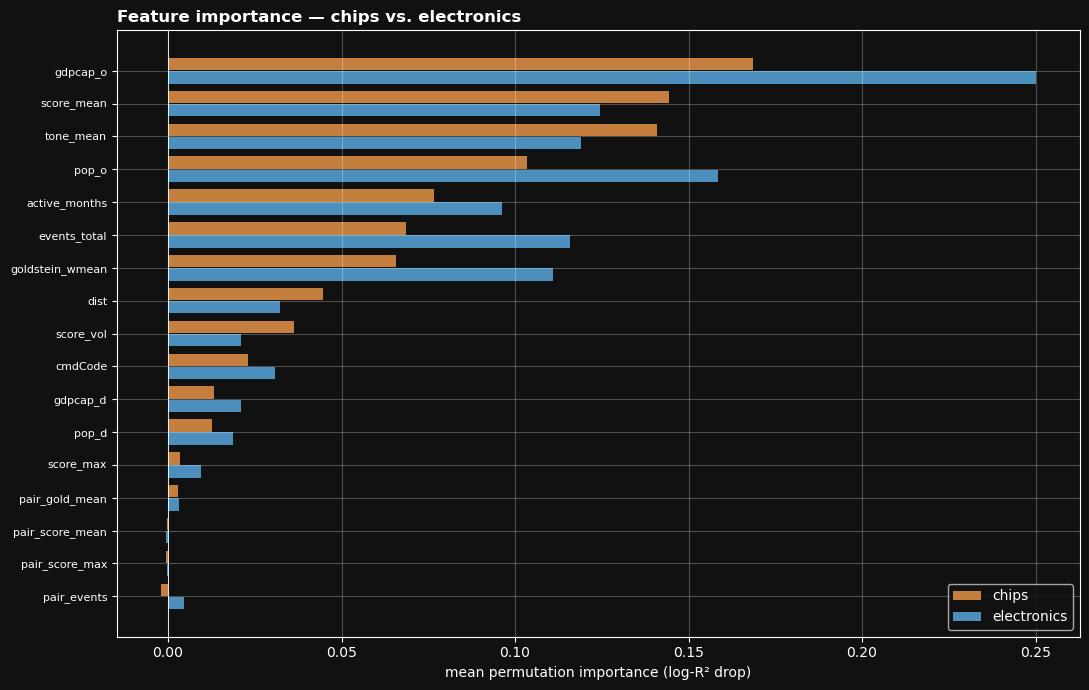

In [7]:
fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(agg))
ax.barh(y - 0.2, agg['chips'], 0.38, label='chips', color=ORANGE)
ax.barh(y + 0.2, agg['electronics'], 0.38, label='electronics', color=BLUE)
ax.set_yticks(y); ax.set_yticklabels(agg.index, fontsize=8)
ax.axvline(0, color='w', lw=.6)
ax.set_xlabel('mean permutation importance (log-R² drop)')
ax.set_title('Feature importance — chips vs. electronics', loc='left', fontweight='bold')
ax.legend(); ax.invert_yaxis()
fig.tight_layout()

## 5. Synthesis

Everything below is computed from the tables above, not hardcoded — rerun this cell after updating any source file and the summary updates with it.

In [8]:
best_overall = overall.iloc[0]
worst_overall = overall.iloc[-1]

print('=== Headline numbers ===')
print(f"Best shrinkage-head config overall: {best_overall['model'].replace('_shrinkage','')} "
      f"(log-R² = {best_overall['log_r2']:.3f})")
print(f"Worst: {worst_overall['model'].replace('_shrinkage','')} (log-R² = {worst_overall['log_r2']:.3f}) "
      f"-- check this one for a training instability before trusting it")
print()
print(f"Pooled+shrinkage beat the dedicated chips-only model in {n_beat}/{len(comp)} configs "
      f"(mean Δ = {comp['delta'].mean():+.3f} log-R²).")
print(f"Worst-performing config in this comparison: {comp['delta'].idxmin()} "
      f"(Δ = {comp['delta'].min():+.3f}) -- worth a closer look before generalizing the headline finding.")
print()
top_feat = agg.drop(columns='abs_gap').mean(axis=1).idxmax()
print(f"Most consistently important feature (both datasets): {top_feat}")
biggest_gap = agg['abs_gap'].idxmax()
print(f"Feature with the biggest chips-vs-electronics importance gap: {biggest_gap} "
      f"(chips={agg.loc[biggest_gap,'chips']:.3f}, electronics={agg.loc[biggest_gap,'electronics']:.3f})")

=== Headline numbers ===
Best shrinkage-head config overall: EdgeGAT_full_blend_ka_tk (log-R² = 0.366)
Worst: GAT_first_topk_attention (log-R² = 0.082) -- check this one for a training instability before trusting it

Pooled+shrinkage beat the dedicated chips-only model in 17/19 configs (mean Δ = +0.136 log-R²).
Worst-performing config in this comparison: GAT_first_topk_attention (Δ = -0.362) -- worth a closer look before generalizing the headline finding.

Most consistently important feature (both datasets): gdpcap_o
Feature with the biggest chips-vs-electronics importance gap: gdpcap_o (chips=0.169, electronics=0.250)
